This script trains a TCN model for possible missing data from upstream probes

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mask_channels_and_create_switches(
    data_array,
    cov_idx,
    tgt_idx,
    group_indices,
    group_to_idx,
    threshold=0.2,
    seed=None,
    plot=False
):
    """
    Masks random probe channels, builds group-level switch based on proportion of active probes,
    and optionally plots probes and switches.

    Returns:
        masked_cov_with_switch: (time, len(cov_idx)+4, 1)
        masked_tgt: (time, len(tgt_idx), 1)
    """
    if seed is not None:
        np.random.seed(seed)

    n_time = data_array.shape[0]
    masked_cov = data_array[:, cov_idx, :].copy()
    masked_tgt = data_array[:, tgt_idx, :].copy()

    n_groups = 4
    switch_array = np.ones((n_time, n_groups, 1), dtype=np.float32)
    group_sizes = {k: len(v) for k, v in group_indices.items()}
    group_mask_counts = {k: 0 for k in group_indices}

    # Random masking per channel
    for i in range(data_array.shape[1]):
        if np.random.rand() < threshold:
            if i in cov_idx:
                masked_cov[:, cov_idx.index(i), :] = 0.0
            if i in tgt_idx:
                masked_tgt[:, tgt_idx.index(i), :] = 0.0

            # data_array[:, i, :] = 0.0  # Mask the channel in the original data
            
            # Track number of masked probes per group
            for group_name, ch_idx in group_indices.items():
                if i in ch_idx:
                    group_mask_counts[group_name] += 1
                    break

    # Update switch based on proportion of masked channels per group
    for group_name, masked_count in group_mask_counts.items():
        proportion_active = 1.0 - masked_count / group_sizes[group_name]
        switch_array[:, group_to_idx[group_name], :] = proportion_active

    # Concatenate switches to masked covariates
    masked_cov_with_switch = np.concatenate([masked_cov, switch_array], axis=1)

    # Optional Plot
    if plot:
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
        fig, ax = plt.subplots(figsize=(12, 6))
        time = np.arange(n_time)

        # Plot all probe channels (by group)
        for group_name, color in zip(group_indices.keys(), colors):
            for i in group_indices[group_name]:
                if i in cov_idx:
                    ax.plot(time, data_array[:, i, 0], color=color, alpha=0.5, lw=1)

        # Plot switches (with thicker lines)
        for i, (group_name, color) in enumerate(zip(group_indices.keys(), colors)):
            ax.plot(time, switch_array[:, i, 0], color=color, lw=3, label=f"{group_name} switch")

        ax.set_title("Masked Probes and Group Switch Signals")
        ax.set_xlabel("Time Step")
        ax.set_ylabel("Amplitude / Switch")
        ax.legend()
        plt.tight_layout()
        plt.show()

    return masked_cov_with_switch, masked_tgt


**IMPORTING + READING FILE + DIVIDING + SCALING**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler

# --- Load and interpolate ---
# fielPath = os.path.dirname(os.path.abspath(__file__))   
# dataPath = os.path.join(fielPath, "waveData.csv")
dataPath = "waveData.csv"

waveData = pd.read_csv(dataPath)
time = waveData["Time"].to_numpy()
prob = waveData.iloc[:, 1:].to_numpy()

time = np.arange(time[0], time[-1], 0.5)
prob_interp = np.zeros((len(time), prob.shape[1]), dtype=np.float32)
for i in range(prob.shape[1]):
    prob_interp[:, i] = np.interp(time, waveData["Time"], prob[:, i])

# --- Convert to TimeSeries ---
start_time = pd.Timestamp("2025-01-01")
datetime_index = start_time + pd.to_timedelta(time, unit="s")

# Upstream as covariates: columns 0–lastCovariateIndex
lastCovariateIndex = 20
df_covariates = pd.DataFrame(prob_interp[:, :lastCovariateIndex], index=datetime_index)
df_covariates.index.name = "Time"
past_covariates = TimeSeries.from_dataframe(df_covariates)

# Downstream as target: columns lastCovariateIndex+
df_target = pd.DataFrame(prob_interp[:, lastCovariateIndex:], index=datetime_index)
df_target.index.name = "Time"
target_series = TimeSeries.from_dataframe(df_target)

# Indices for covariates and targets
cov_idx = list(range(0, lastCovariateIndex))   # upstream probes
tgt_idx = list(range(lastCovariateIndex, 24))  # downstream probes


# --- Train/Validation split ---
train_target, val_target = target_series.split_after(0.75)
train_cov, val_cov = past_covariates.split_after(0.75)

# --- Scale data ---
scaler_target = Scaler()
scaler_cov = Scaler()

train_target_scaled = scaler_target.fit_transform(train_target)
val_target_scaled = scaler_target.transform(val_target)
full_target_scaled = scaler_target.transform(target_series)

train_cov_scaled = scaler_cov.fit_transform(train_cov)
val_cov_scaled = scaler_cov.transform(val_cov)
full_cov_scaled = scaler_cov.transform(past_covariates)


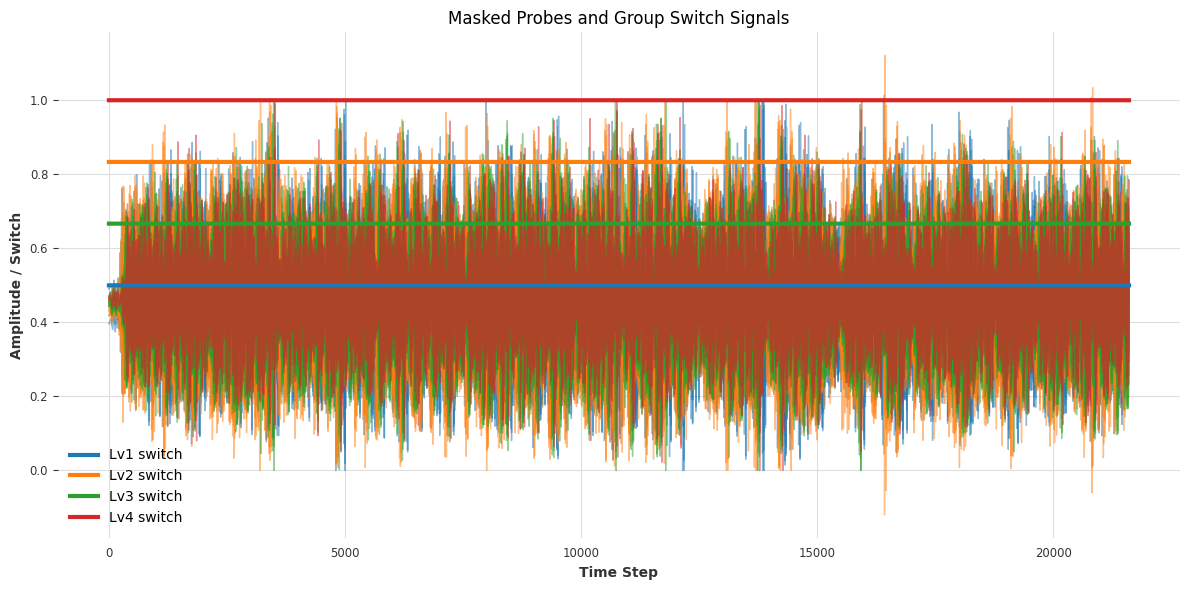

In [3]:
# Define Probe groupings

# Total 24 probes (0–23): 0–20 upstream (cov), 21–23 downstream (target)
group_labels = ['Lv1', 'Lv2', 'Lv3', 'Lv4']
group_indices = {
    group_labels[0]: list(range(0, 6)),
    group_labels[1]: list(range(6, 12)),
    group_labels[2]: list(range(12, 18)),
    group_labels[3]: list(range(18, 24))
}
group_to_idx = {name: i for i, name in enumerate(group_labels)}

# Use scaled data for training
data_array = full_target_scaled.stack(full_cov_scaled).all_values(copy=True)

# Apply masking
masked_cov_array, masked_tgt_array = mask_channels_and_create_switches(
    data_array=data_array,
    cov_idx=cov_idx,
    tgt_idx=tgt_idx,
    group_indices=group_indices,
    group_to_idx=group_to_idx,
    threshold=0.2,
    seed=41,
    plot=True
)




**CREATE THE MODEL THAT IS SENSITIVE TO MISSING DATA**

In [4]:
from darts.models import TCNModel
from darts import TimeSeries

# --- Settings ---
m = 120
n = 40
e = 100
threshold = 0.2
time_idx = full_target_scaled.time_index

# --- Create TCN model ---
model = TCNModel(
    input_chunk_length=m,
    output_chunk_length=n,
    n_epochs=1,
    kernel_size=3,
    num_filters=3,
    num_layers=4,
    dropout=0.1,
    weight_norm=True,
    random_state=41
)

# Stack all channels for joint masking (shape: [T, 24, 1])
data_array = full_target_scaled.stack(full_cov_scaled).all_values(copy=True)

# ---- Training Loop ----
for epoch in range(e):
    # Generate randomized masked input
    masked_cov_array, masked_tgt_array = mask_channels_and_create_switches(
        data_array=data_array,
        cov_idx=cov_idx,
        tgt_idx=tgt_idx,
        group_indices=group_indices,
        group_to_idx=group_to_idx,
        threshold=threshold,
        seed=None,  # random every time
        plot=False
    )

    # Convert to TimeSeries
    masked_cov_ts = TimeSeries.from_times_and_values(time_idx, masked_cov_array)
    masked_tgt_ts = TimeSeries.from_times_and_values(time_idx, masked_tgt_array)

    # Train for one epoch
    model.fit(series=masked_tgt_ts, past_covariates=masked_cov_ts, verbose=True)

    print(f"Epoch {epoch + 1} completed.")

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | res_blocks      | ModuleList       | 603    | train
-------------------------------------------------------------
603       Trainable params
0         Non-trainable params
603       Total params
0.002     Total estimated model params size (MB)
52        Modules in train mode
0         Modules in eval mode
/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on M

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Attempting to retrain/fine-tune the model without resuming from a checkpoint. This is currently discouraged. Consider model `TCNModel.load_weights()` to load the weights for fine-tuning.


Epoch 1 completed.


/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

Epoch 99 completed.


/Users/ralkarem/anaconda3/envs/dolEnv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1` reached.


Epoch 100 completed.
